<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_de_estudio_arboles_de_regresiOn_y_bosques_aleatorios_PCT_BATEO_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto de los datos

El conjunto de datos trata con información relacionada al deporte del beisbol; con características de los jugadores bateadores de *Major League Baseball* (*MLB*) con el propósito de construir y evaluar modelos de aprendizaje automático orientados a la predicción del porcentaje de bateo.

El *dataset* integra variables demográficas, antropométricas, deportivas y biomecánicas que pueden influir en el desempeño ofensivo de un jugador profesional de béisbol.

La información contiene registros históricos correspondientes a múltiples jugadores y temporadas, permitiendo aplicar técnicas de de regresión como arboles de regresión, bosques aleatorios y regresión lineal múltiple.

Las variables independientes:

-   *edad*: Edad del jugador expresada en años,
-   *experiencia_mlb*: Número de años de experiencia del jugador en Grandes Ligas,
-   *estatura_cm*: Estatura del jugador en centímetros,
-   *peso_kg*: el peso corporal de un jugador medido en kilogramos,
-   *velocidad_swing*: Velocidad del movimiento del *swing* del bate,
-   *fuerza*: Indicador asociado a la fuerza física del jugador,
-   *precision_contacto*: Capacidad del jugador para realizar contacto efectivo con la pelota,
-   *vision_dinamica*: Capacidad visual para seguir y reaccionar al movimiento de la pelota,
-   *agilidad*: Indicador de movilidad y rapidez corporal,
-   *tiempo_reaccion*: Tiempo de reacción del jugador ante el lanzamiento

Variable dependiente: * *pct_bateo*: Porcentaje de bateo del jugador.

El caso de estudio se encuentra en *google collab*: https://colab.research.google.com/drive/1EZZbKthfWRQ9IBn3I8lYWU9q85jtH2rK?usp=sharing .


https://colab.research.google.com/drive/1EZZbKthfWRQ9IBn3I8lYWU9q85jtH2rK?usp=sharing

De igual forma, el caso puede descargarse desde *github.com*: https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Caso_de_estudio_arboles_de_regresiOn_y_bosques_aleatorios_PCT_BATEO.ipynb .

Los datos se encuentran en el enlace de *girthub.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_mlb_porcentaje_de_bateo.csv .

Las funcipnes se encuentran en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20ARBOLES%20DE%20REGRESION%20RANDOM%20FOREST%20LINEAL%20MULTIPLE%20PARA%20PCT_BATEO.py


# Objetivo

Construir, evaluar y comprar modelos predictivos árboles de regresión, bosques aleatoriso y regresión lienal múltiple con datos de porcentajes de bateo de jugadores de beisbol.

Los modelos serán aceptados si tienen valores de *r square* y *r square ajustado* por encima del *50%*

Los datos originales no se escalan ni se estandarizan, de tal forma que los modelos utilizan los datos originales

Las particiones serán *70%* para datos de entrenamiento y *30%* para datos de validación.

Al final el caso de estudio deberá indicar cual es el mejor modelo predictivo con estos datos.



# Descripción

Se cargan librerías, funciones, datos y se muestran los estaísticos descriptivos de los datos.


## Cargar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
from sklearn.metrics import ( mean_squared_error,
    mean_absolute_error,  r2_score )

from scipy.stats import shapiro
from scipy.stats import kstest
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm

# Para validar posutalados
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor)
from statsmodels.stats.diagnostic import (het_breuschpagan,
    linear_reset)
from statsmodels.stats.stattools import ( durbin_watson)
from scipy.stats import ( shapiro)
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import anderson
from sklearn.linear_model import (  LassoCV)
from sklearn.linear_model import (  RidgeCV)
from sklearn.preprocessing import (PolynomialFeatures)
from sklearn.svm import SVR # Para modelos SVR

# Para arboles de regresión y bosques aleatorios
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

# Cargar funciones

In [2]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20ARBOLES%20DE%20REGRESION%20RANDOM%20FOREST%20LINEAL%20MULTIPLE%20PARA%20PCT_BATEO.py"
import requests

exec(requests.get(url).text)

# Cargar datos

In [3]:
URL = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_mlb_porcentaje_de_bateo.csv"
datos = f_cargar_datos(URL)

## Visualizar datos


In [4]:
f_visualizar_head_tail_reducido(datos)

,edad,experiencia_mlb,estatura_cm,peso_kg,...,vision_dinamica,agilidad,tiempo_reaccion,pct_bateo
0,39,21,176.8,76.4,...,77.3,72.7,0.253,0.297
1,39,18,178.1,95.5,...,81.3,75.7,0.25,0.283
2,28,6,170.5,97.3,...,77.1,74.9,0.275,0.303
3,25,6,174.2,88.5,...,81.7,72.1,0.286,0.289
4,28,8,183.0,89.0,...,74.8,71.0,0.231,0.269
5,39,19,191.4,110.0,...,80.2,73.9,0.258,0.285
6,...,...,...,...,...,...,...,...,...
7,31,10,168.5,80.4,...,83.0,71.8,0.262,0.293
8,32,11,183.2,80.7,...,83.7,73.4,0.279,0.31
9,33,13,181.4,83.6,...,81.2,81.7,0.251,0.312


## Estadísticos descriptivos


In [5]:
f_describir_datos(datos)

{'describe':               edad  experiencia_mlb  estatura_cm      peso_kg  \
 count  4500.000000      4500.000000  4500.000000  4500.000000   
 mean     29.486222         9.057111   184.948689    88.215222   
 std       5.814693         5.915616     6.994931    10.037099   
 min      20.000000         0.000000   162.000000    53.600000   
 25%      24.000000         4.000000   180.375000    81.500000   
 50%      29.000000         9.000000   184.900000    88.200000   
 75%      35.000000        14.000000   189.600000    95.100000   
 max      39.000000        21.000000   211.900000   129.500000   
 
        velocidad_swing       fuerza  precision_contacto  vision_dinamica  \
 count      4500.000000  4500.000000         4500.000000      4500.000000   
 mean        111.925911    81.957822           80.129400        79.059089   
 std           6.953679     5.921254            5.042408         3.980231   
 min          86.500000    62.100000           61.400000        64.300000   
 25%   

# Desarrollo

## Datos de entrenamiemnto y validación


In [6]:
particiones = f_particionar_datos(datos)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(datos_entrenamiento)

,edad,experiencia_mlb,estatura_cm,peso_kg,...,vision_dinamica,agilidad,tiempo_reaccion,pct_bateo
0,32,10,186.6,92.3,...,80.5,81.9,0.253,0.299
1,22,0,191.6,93.0,...,80.2,77.4,0.263,0.281
2,26,7,186.0,89.1,...,81.8,89.5,0.29,0.314
3,22,1,185.9,93.4,...,77.5,75.4,0.281,0.293
4,21,3,187.5,86.7,...,79.9,68.9,0.272,0.272
5,36,16,182.8,97.3,...,86.7,75.1,0.284,0.297
6,...,...,...,...,...,...,...,...,...
7,31,8,177.7,94.4,...,76.7,78.1,0.255,0.25
8,27,4,187.2,102.0,...,77.2,73.1,0.278,0.295
9,21,0,176.0,94.5,...,81.7,71.0,0.271,0.309


In [7]:
f_visualizar_head_tail_reducido(datos_validacion)

,edad,experiencia_mlb,estatura_cm,peso_kg,...,vision_dinamica,agilidad,tiempo_reaccion,pct_bateo
0,30,12,173.8,73.9,...,79.8,79.0,0.25,0.278
1,29,11,188.2,70.9,...,82.2,82.7,0.274,0.323
2,36,18,181.1,79.1,...,81.9,72.1,0.319,0.298
3,28,6,189.0,88.7,...,82.5,81.1,0.272,0.274
4,24,4,182.3,89.8,...,75.3,77.4,0.273,0.269
5,23,0,190.9,114.3,...,81.3,74.4,0.289,0.284
6,...,...,...,...,...,...,...,...,...
7,39,21,180.0,86.3,...,71.7,70.9,0.226,0.266
8,36,16,184.8,97.5,...,79.3,74.0,0.271,0.302
9,26,7,179.0,65.8,...,83.8,73.0,0.279,0.315


## Modelo árboles de regresión (AR)

Se construye el modelo árboles de regresión con la con la función *f_crear_modelo_AR()* con los datos de entrenamiento y la variable dependiente "pct_bateo" y una profunidad de *4* niveles.

In [8]:
modelo_AR = f_crear_modelo_AR(datos_entrenamiento, "pct_bateo", max_depth=4)
modelo_AR

MODELO ÁRBOL DE REGRESIÓN
Variable dependiente : pct_bateo
Observaciones        : 3150
Variables            : 10
Profundidad máxima   : 4


DecisionTreeRegressor(max_depth=4, random_state=2026)

### Reglas de decisión del modelo AR


In [9]:
f_reglas_modelo_AR(modelo_AR, datos_entrenamiento,"pct_bateo")



REGLAS DE DECISIÓN DEL ÁRBOL DE REGRESIÓN
|--- precision_contacto <= 81.75
|   |--- velocidad_swing <= 112.55
|   |   |--- precision_contacto <= 75.95
|   |   |   |--- precision_contacto <= 70.85
|   |   |   |   |--- value: [0.25]
|   |   |   |--- precision_contacto >  70.85
|   |   |   |   |--- value: [0.26]
|   |   |--- precision_contacto >  75.95
|   |   |   |--- vision_dinamica <= 80.45
|   |   |   |   |--- value: [0.27]
|   |   |   |--- vision_dinamica >  80.45
|   |   |   |   |--- value: [0.28]
|   |--- velocidad_swing >  112.55
|   |   |--- precision_contacto <= 76.25
|   |   |   |--- vision_dinamica <= 79.15
|   |   |   |   |--- value: [0.27]
|   |   |   |--- vision_dinamica >  79.15
|   |   |   |   |--- value: [0.28]
|   |   |--- precision_contacto >  76.25
|   |   |   |--- vision_dinamica <= 78.45
|   |   |   |   |--- value: [0.28]
|   |   |   |--- vision_dinamica >  78.45
|   |   |   |   |--- value: [0.29]
|--- precision_contacto >  81.75
|   |--- velocidad_swing <= 112.55

'|--- precision_contacto <= 81.75\n|   |--- velocidad_swing <= 112.55\n|   |   |--- precision_contacto <= 75.95\n|   |   |   |--- precision_contacto <= 70.85\n|   |   |   |   |--- value: [0.25]\n|   |   |   |--- precision_contacto >  70.85\n|   |   |   |   |--- value: [0.26]\n|   |   |--- precision_contacto >  75.95\n|   |   |   |--- vision_dinamica <= 80.45\n|   |   |   |   |--- value: [0.27]\n|   |   |   |--- vision_dinamica >  80.45\n|   |   |   |   |--- value: [0.28]\n|   |--- velocidad_swing >  112.55\n|   |   |--- precision_contacto <= 76.25\n|   |   |   |--- vision_dinamica <= 79.15\n|   |   |   |   |--- value: [0.27]\n|   |   |   |--- vision_dinamica >  79.15\n|   |   |   |   |--- value: [0.28]\n|   |   |--- precision_contacto >  76.25\n|   |   |   |--- vision_dinamica <= 78.45\n|   |   |   |   |--- value: [0.28]\n|   |   |   |--- vision_dinamica >  78.45\n|   |   |   |   |--- value: [0.29]\n|--- precision_contacto >  81.75\n|   |--- velocidad_swing <= 112.55\n|   |   |--- prec

### Visualizando arbol de regresión
Se visualiza el árbol de regresión a *4* niveles de profundidad, similar a lo que de manera natural lo construyó *R* para estos datos.


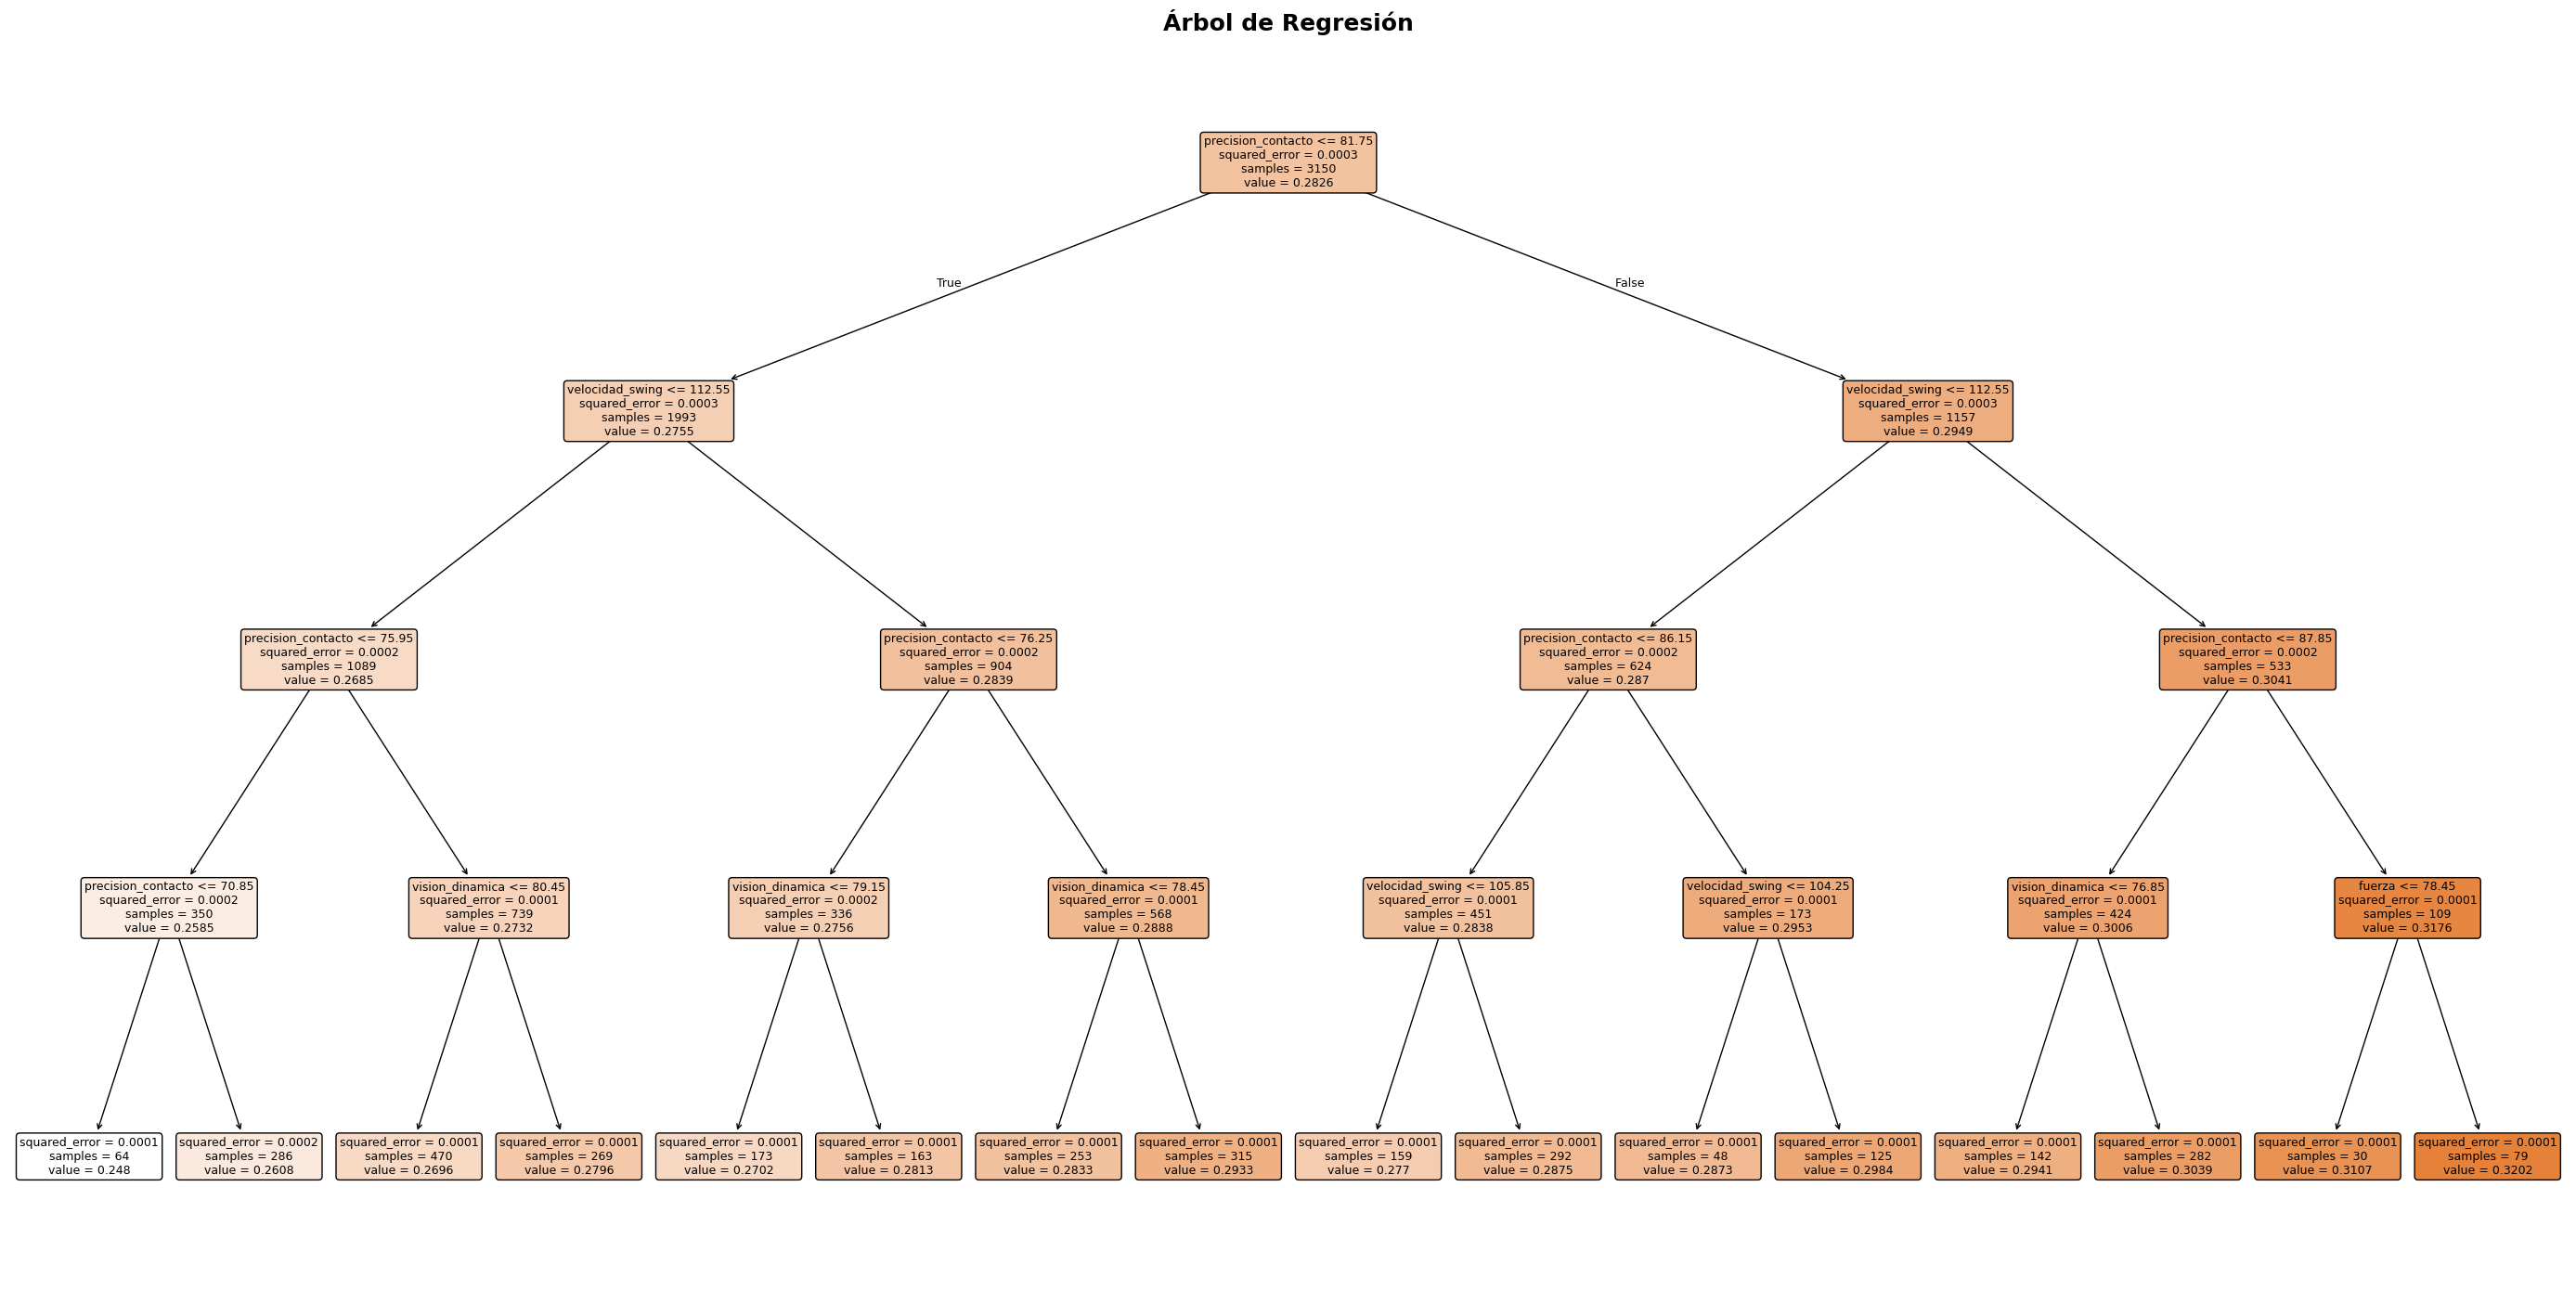

In [10]:
f_visualizar_modelo_AR(modelo_AR, datos_entrenamiento, "pct_bateo")

### Variables importantes de AR

Se observa que las variables significativas para el modelo de árboles de regresión son *precision_contacto*, *velocidad_swing* y *vision_dinamica* como atributos técnicos del jugador para imparctar en las predicciones del porcentaje de bateo de manera importante .



In [11]:
f_variables_importantes(modelo_AR, datos_entrenamiento, "pct_bateo")

,Variable,Importancia,Porcentaje
0,precision_contacto,0.6055,60.55
1,velocidad_swing,0.3177,31.77
2,vision_dinamica,0.0740,7.40
3,fuerza,0.0029,0.29
4,experiencia_mlb,0.0000,0.00
5,edad,0.0000,0.00
6,estatura_cm,0.0000,0.00
7,peso_kg,0.0000,0.00
8,agilidad,0.0000,0.00
9,tiempo_reaccion,0.0000,0.00


## Modelo random forest (RF)

Se cosntruye el modelo bosques aletorios o *random forest* con la función *f_crear_RF()* que recibe los argimentos de los datos de entrenamiento, la variabe dependiente *pct_bateo* y el número de árboles en el parámetro *n_estimators*.

In [12]:
modelo_RF = f_crear_RF(datos_entrenamiento, "pct_bateo", n_estimators=500)
modelo_RF

MODELO BOSQUE ALEATORIO DE REGRESIÓN
Variable dependiente : pct_bateo
Observaciones        : 3150
Variables            : 10
Número de árboles    : 500


RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=2026)

### Variables principales

Con la función *f_variables_importantes()* se identifican las variable importantes en el modelo *random forest* . Este modelo de *random forest*, al igual que el modelo de árboles de regesión, también indica que las variable imkportante son para predecir el porcentaje de abteo son de tipo técnico o habilidades en relación a la biomecánica de bateo de un judgador de beisbol; estas variables de importancia son *precision_contacto*, *velocidad_swing* y *vision_dinamica*.  



In [13]:
f_variables_importantes(modelo_RF, datos_entrenamiento, "pct_bateo")

,Variable,Importancia,Porcentaje
0,precision_contacto,0.4315,43.15
1,velocidad_swing,0.2858,28.58
2,vision_dinamica,0.0985,9.85
3,agilidad,0.0606,6.06
4,fuerza,0.0553,5.53
5,tiempo_reaccion,0.0249,2.49
6,estatura_cm,0.0143,1.43
7,peso_kg,0.0136,1.36
8,edad,0.0080,0.80
9,experiencia_mlb,0.0076,0.76


## Modelo regresión lineal múltiple

Se construye el modelo de regresión lineal múltiple con la función descrita anterioremente para otros casos de estudio; *f_construir_modelo_RLM_statsmodels()*.

In [14]:
modelo_RLM = f_construir_modelo_RLM_statsmodels(datos_entrenamiento, "pct_bateo")
modelo_RLM

                            OLS Regression Results                            
Dep. Variable:              pct_bateo   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     2675.
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        15:25:09   Log-Likelihood:                 11655.
No. Observations:                3150   AIC:                        -2.329e+04
Df Residuals:                    3139   BIC:                        -2.322e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.2429      0

## Validación de postulados


Se manda llamar la función ** que valida sobre todo el modelo de regresión ñineal multipl eya que los modelso de arboles de regresión y bosaques aleatorios siendo modelos no paramétricos no se validan con estos postulados de regresión.



In [15]:
resultado_postulados = f_validar_postulados_modelos( modelos=[modelo_RLM,
        modelo_AR,   modelo_RF ],
    datos_list = [datos_validacion,datos_validacion,datos_validacion],
    variable_dependiente="pct_bateo",
    nombres = ["RLM", "Arboles de regresión", "Random Forest"] )


VALIDACIÓN DE POSTULADOS
                 Modelo           Tipo  VIF_Max Linealidad Homocedasticidad  \
0                   RLM         lineal   12.406     Cumple           Cumple   
1  Arboles de regresión          arbol      NaN  No aplica        No aplica   
2         Random Forest  random_forest      NaN  No aplica        No aplica   

  Normalidad Independencia  
0     Cumple        Cumple  
1  No aplica     No aplica  
2  No aplica     No aplica  


## Evaluación de modelos

Ahora, ejecutando la función *f_evaluacion_modelos()* se generan los estaídticos aue permiten evalura la calidad predictiva de los modelos construidos en este caso de estudio.


In [16]:
f_evaluacion_modelos(modelos=[modelo_RLM, modelo_AR, modelo_RF],
    datos_validacion=datos_validacion,
    variable_dependiente="pct_bateo",
    nombres=["RLM", "Árbol de Regresión", "Random Forest"] )


EVALUACIÓN DE MODELOS
               Modelo           Tipo  Parametros  R_square  R_square_ajustado  \
0                 RLM         lineal          10    0.8955             0.8947   
1       Random Forest  random_forest         500    0.8408                NaN   
2  Árbol de Regresión          arbol          16    0.6005                NaN   

      MSE    RMSE     MAE  
0  0.0000  0.0060  0.0048  
1  0.0001  0.0074  0.0059  
2  0.0001  0.0118  0.0093  


,Modelo,Tipo,Parametros,R_square,R_square_ajustado,MSE,RMSE,MAE
0,RLM,lineal,10,0.8955,0.8947,0.0000,0.0060,0.0048
1,Random Forest,random_forest,500,0.8408,NaN,0.0001,0.0074,0.0059
2,Árbol de Regresión,arbol,16,0.6005,NaN,0.0001,0.0118,0.0093


## Visualizar predicciones


Con la ejecución de la función *f_visualizar_prediccones()* se observa que los modelos de regresión lineal múltiple y *random forest* ofrecen mejor calidad predictiva con un valor por encima del *80%* en *r swuare*. Además, los valores de *RMSE* de *0.006* y *0.007* en ambos modelos significa el rango que pueden variar las predicciones del porcentaje de bateo de un jugador de beisbol.


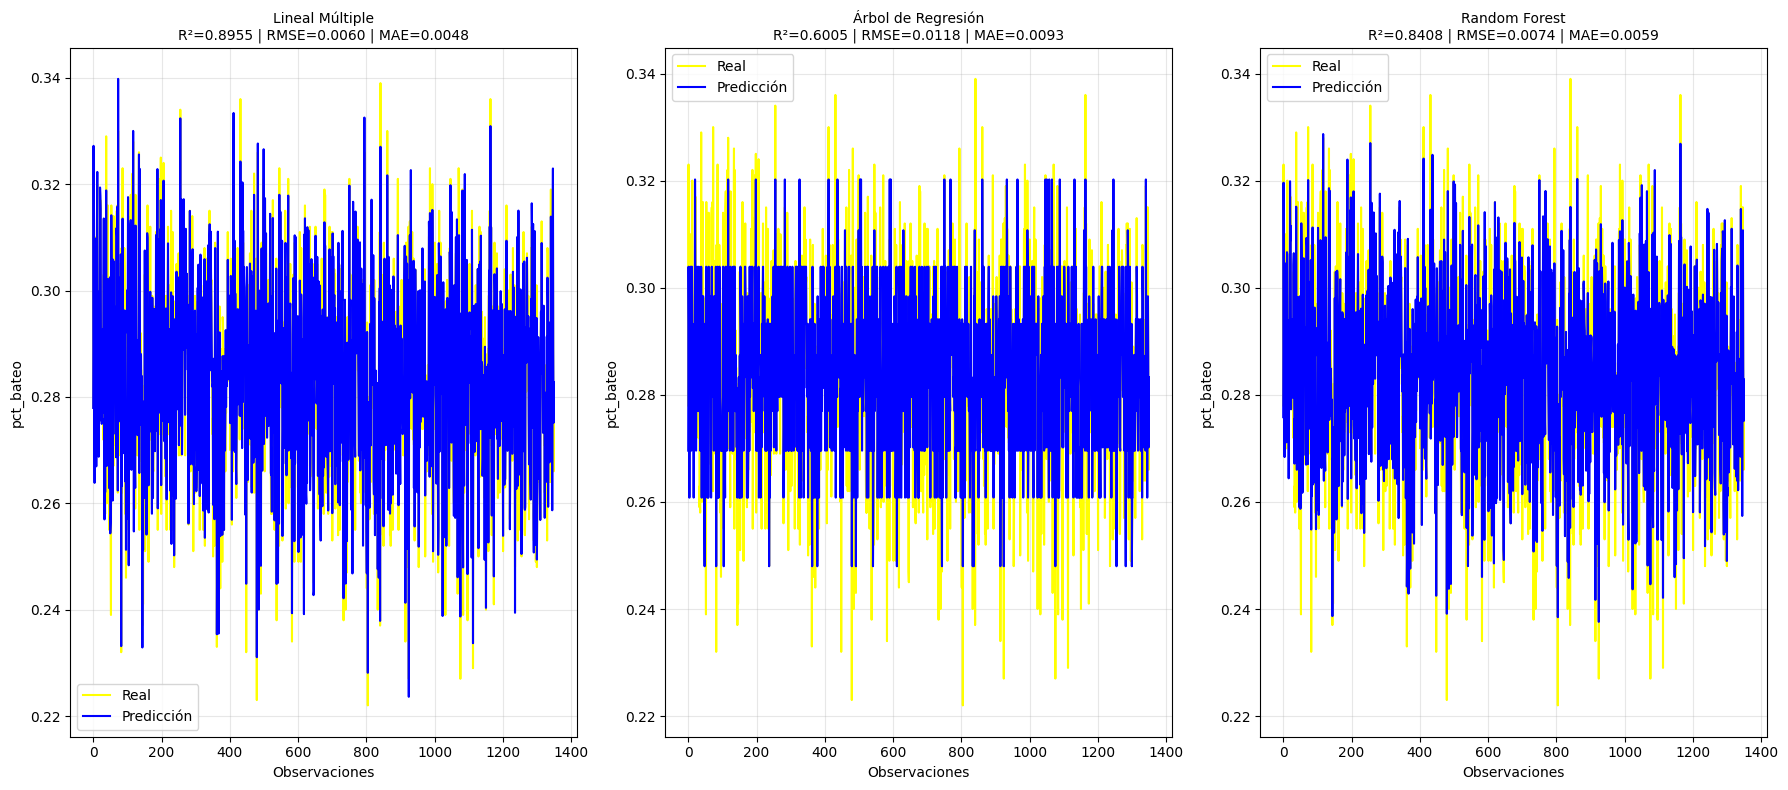

In [17]:
f_visualizar_predicciones(modelos=[modelo_RLM, modelo_AR, modelo_RF],
    datos=datos_validacion,
    variable_dependiente="pct_bateo",
  nombres_modelos=["Lineal Múltiple", "Árbol de Regresión", "Random Forest"],
    ordenar=False,
    tipo_grafico="linea",
    figsize=(18,8)
)

# Interpretación del caso


Se cumple con el objetivo del caso de estudio de construir , evaluar y comparar los modelos de regresión.  

Se construyeron tres modelos de predictivos, árboles de regresión, bosques aleatorios y regresión lineal múltiple con datos de porcentaje de bateo de jugadores de beisbol.

Todos los modelos utilizaron datos originales sin estandarizar ni escalar valores; del todal de los datos, el *70%* fue para datos de entrenamiento y el *30%* para datos de validación.

Todos los modelos tuvieron calidad predictiva por encimal del *50%* de acuerdo con el estadístico de evaluaicón *r square* y satisfacen la expectativa inicialmente establecida de ser mayor del 50% para este caso de estudio.

De los tres modelos construidos, el modelo que mejor calidad predictiva ofrece para estos datos es el de regresión lineal múltiple.




